## 1. Importing required libraries and loading the dataset


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from transformers import MarianMTModel, MarianTokenizer
import torch
import random

df = pd.read_csv('../data/raw/financial_news.csv')

## 2. Analyze Class Distribution
Let's analyze the initial distribution of the sentiment classes.

Original dataset shape: Counter({'positive': 4114, 'negative': 3891, 'neutral': 880})


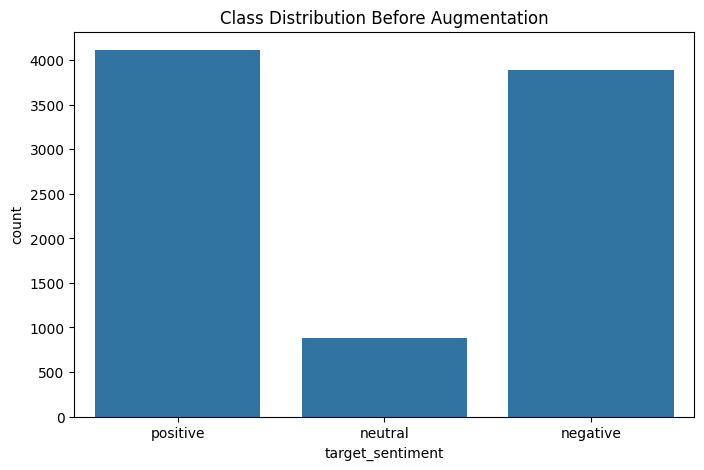

In [6]:
print(f"Original dataset shape: {Counter(df['target_sentiment'])}")

plt.figure(figsize=(8, 5))
sns.countplot(x='target_sentiment', data=df, order=['positive', 'neutral', 'negative'])
plt.title('Class Distribution Before Augmentation')
plt.show()

## 3. Load and Initialize Translation Models

To handle class imbalance, we are going to use an augmentation technique named Back Translation. Basically, this technique consists of translating the Spanish text to English, and then translating it back from English to Spanish. This process produces different texts with the same meaning.
I found this article really interesting: https://medium.com/walmartglobaltech/augmentation-techniques-for-imbalanced-text-classification-f0d29c0f8ce1

In [7]:
# Initialize Spanish to English translator
es_to_en_model_name = "Helsinki-NLP/opus-mt-es-en"
es_to_en_tokenizer = MarianTokenizer.from_pretrained(es_to_en_model_name)
es_to_en_model = MarianMTModel.from_pretrained(es_to_en_model_name)

# Initialize English to Spanish translator
en_to_es_model_name = "Helsinki-NLP/opus-mt-en-es"
en_to_es_tokenizer = MarianTokenizer.from_pretrained(en_to_es_model_name)
en_to_es_model = MarianMTModel.from_pretrained(en_to_es_model_name)

c:\Users\eucli\anaconda3\envs\FinancialNewsSentimentAnalysis\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\eucli\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-es-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\eucli\anaconda3\envs\FinancialNewsSentimentAnalysis\Lib\site-packages\tr

## 4. Create Back Translation Function

In [8]:
def back_translate_text(text, 
                        es_to_en_tokenizer, 
                        es_to_en_model, 
                        en_to_es_tokenizer, 
                        en_to_es_model):
    """
    Perform back translation: Spanish -> English -> Spanish
    """
    try:
        # Spanish to English
        inputs = es_to_en_tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            translated = es_to_en_model.generate(**inputs, max_length=512)
        english_text = es_to_en_tokenizer.decode(translated[0], skip_special_tokens=True)
        
        # English to Spanish
        inputs = en_to_es_tokenizer(english_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            back_translated = en_to_es_model.generate(**inputs, max_length=512)
        spanish_text = en_to_es_tokenizer.decode(back_translated[0], skip_special_tokens=True)
        
        return spanish_text
    except Exception as e:
        print(f"Error in back translation: {e}")
        # Return original if translation fails
        return text  

## 5. Calculate Required Augmentation

In [9]:
# Current distribution: positive=4114, negative=3891, neutral=880
# Target: Balance neutral to match the average of positive and negative
target_neutral_count = int((4114 + 3891) / 2)  # approximately 4000
current_neutral_count = 880
# It's necessary to create around 3120 new samples
samples_needed = target_neutral_count - current_neutral_count  

## 6. Filter and Augment Neutral Class

In [10]:
# Filter neutral samples
neutral_samples = df[df['target_sentiment'] == 'neutral']['text'].tolist()

# Generate augmented samples
augmented_samples = []
iterations_per_sample = samples_needed // len(neutral_samples) + 1

for iteration in range(iterations_per_sample):
    for original_text in neutral_samples:
        if len(augmented_samples) >= samples_needed:
            break
        
        # Perform back translation
        augmented_text = back_translate_text(
            original_text, es_to_en_tokenizer, es_to_en_model,
            en_to_es_tokenizer, en_to_es_model
        )
        
        # Add slight randomization by varying translation parameters if needed
        # Only add if translation changed the text
        if augmented_text != original_text:  
            augmented_samples.append(augmented_text)
    
    if len(augmented_samples) >= samples_needed:
        break
    
print(f"Generated {len(augmented_samples)} augmented samples.")
print(augmented_samples[:10]) 

Generated 2888 augmented samples.
['Alquilar un apartamento compartido en Aragón cuesta en promedio 252 euros al mes', 'Huelgas de reforma', 'El misterio de quién inventó el bitcoin llega a juicio', 'Repsol somete a su junta de accionistas este viernes el pago de un dividendo suplementario de 0,45 euros', 'Airef considera que la política presupuestaria es "muy similar" a la de otros años', 'Picardo: "Un duro "brexit" para el Reino Unido amenazaría la economía de Gibraltar"', '¿Qué es el Registro Mercantil?', 'La inflación de la zona del euro se mantiene en el 0,2% en agosto', 'Las coberturas de seguros de automóviles menos conocidas', 'Así es como la política de Trump afecta a diez empresas']


## 7.  Create Balanced Dataset

In [13]:
# Adjust to use actual length of augmented samples
actual_samples_count = len(augmented_samples)

# Create DataFrame for augmented samples
augmented_df = pd.DataFrame({
    'text': augmented_samples,
    'target_sentiment': ['neutral'] * actual_samples_count
})

# Combine with original dataset
balanced_df = pd.concat([df, augmented_df], ignore_index=True)


## 8. Checking the dataset after applying Augmetation.

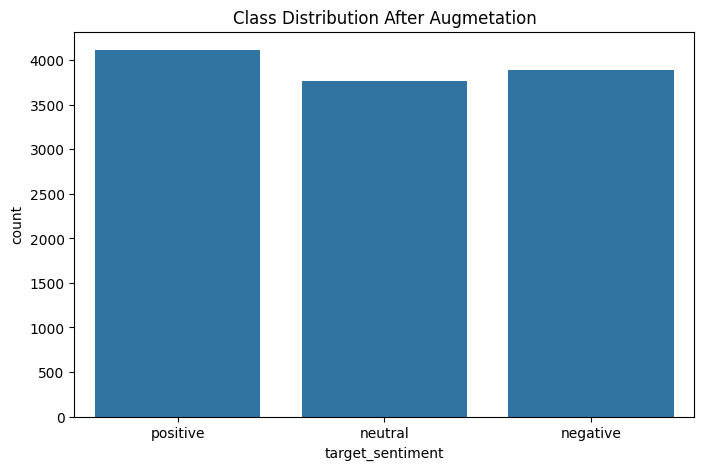

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='target_sentiment', data=balanced_df, order=['positive', 'neutral', 'negative'])
plt.title('Class Distribution After Augmetation')
plt.show()

## 6. Saving the Resampled Dataset

We will now save the final resampled dataset. The 'text' for synthetic samples will be a placeholder, but the embeddings (`X_resampled`) are the key features for model training.

In [15]:

balanced_df.to_csv('../data/processed/financial_news_balanced.csv', index=False)
